In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("titanic.csv")
print("Data Shape:", df.shape)

Data Shape: (887, 8)


In [4]:
print("\nData Types:\n", df.dtypes)


Data Types:
 Survived                     int64
Pclass                       int64
Name                        object
Sex                         object
Age                        float64
Siblings/Spouses Aboard      int64
Parents/Children Aboard      int64
Fare                       float64
dtype: object


In [5]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
dtype: int64


In [7]:
df.describe(include='all')

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
count,887.000000,887.000000,887,887,887.000000,887.000000,887.000000,887.00000
unique,NaN,NaN,887,2,NaN,NaN,NaN,NaN
top,NaN,NaN,Mr. Owen Harris Braund,male,NaN,NaN,NaN,NaN
freq,NaN,NaN,1,573,NaN,NaN,NaN,NaN
mean,0.385569,2.305524,NaN,NaN,29.471443,0.525366,0.383315,32.30542
std,0.487004,0.836662,NaN,NaN,14.121908,1.104669,0.807466,49.78204
min,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,0.00000
25%,0.000000,2.000000,NaN,NaN,20.250000,0.000000,0.000000,7.92500
50%,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,14.45420
75%,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,31.13750


Text(0.5, 1.0, 'Fare by Class')

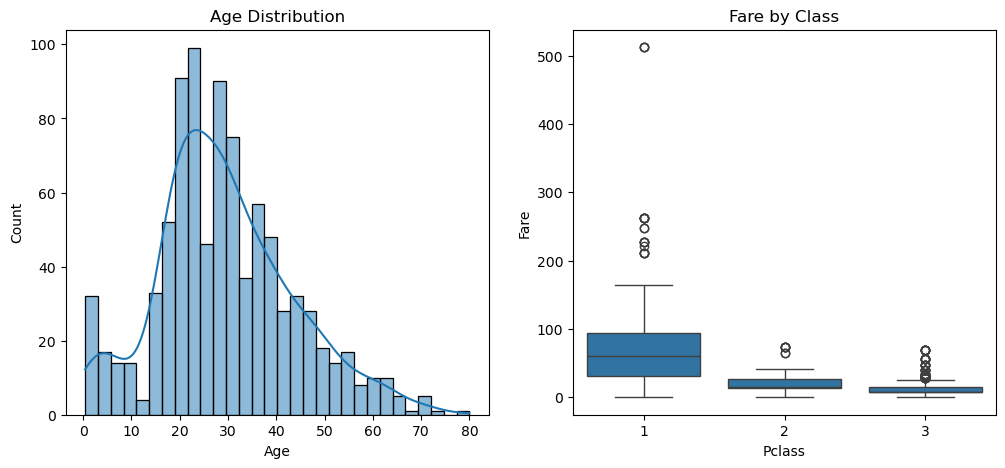

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['Age'], bins=30, kde=True, ax=ax[0]).set_title('Age Distribution')
sns.boxplot(x='Pclass', y='Fare', data=df, ax=ax[1]).set_title('Fare by Class')

Text(0.5, 1.0, 'Survival by Gender')

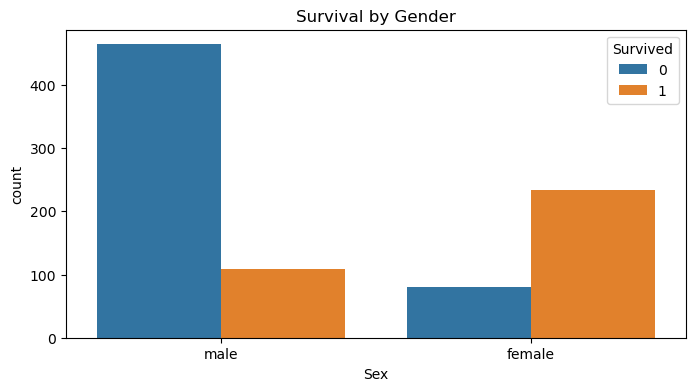

In [11]:
plt.figure(figsize=(8, 4))
sns.countplot(x='Sex', hue='Survived', data=df).set_title('Survival by Gender')

<Axes: >

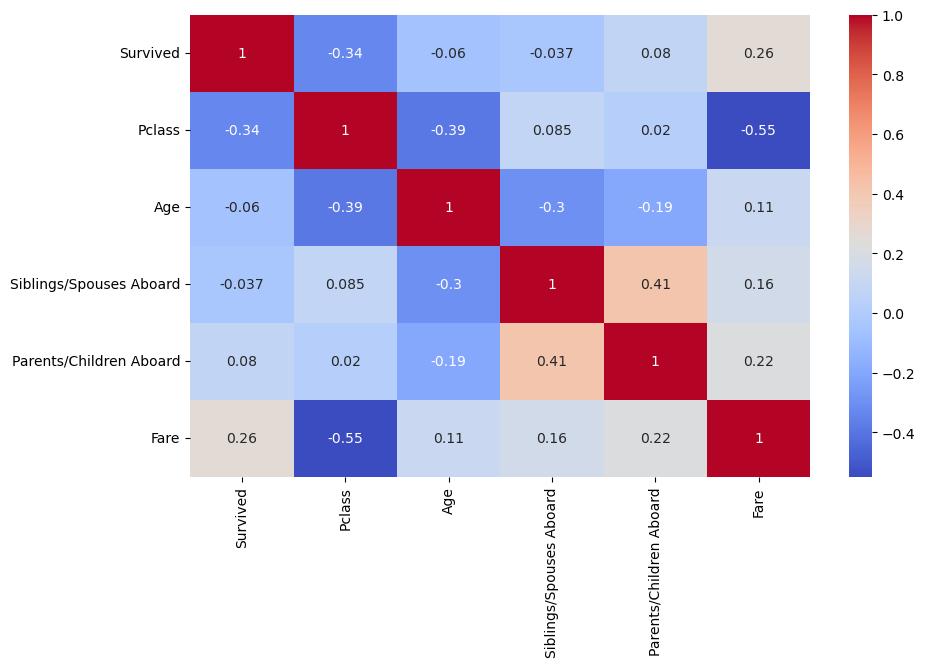

In [12]:
# Correlation Matrix (Heatmap)
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [13]:
pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.564682,24.435318


Text(0.5, 1.0, 'Fare Outliers')

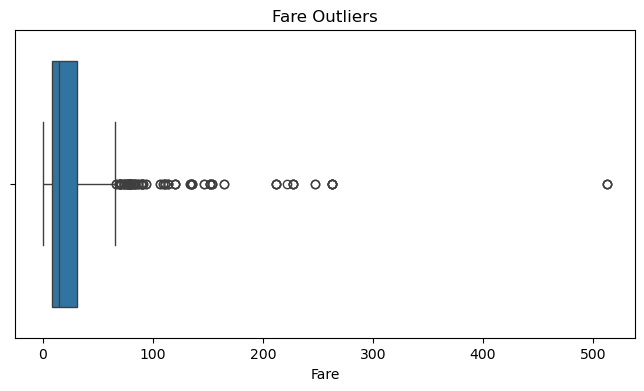

In [14]:
# Boxplot for Fare Outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Fare']).set_title('Fare Outliers')

In [15]:
from scipy import stats
z_scores = np.abs(stats.zscore(df['Fare']))
outliers = df[z_scores > 3]
print(f"Found {len(outliers)} fare outliers")

Found 20 fare outliers


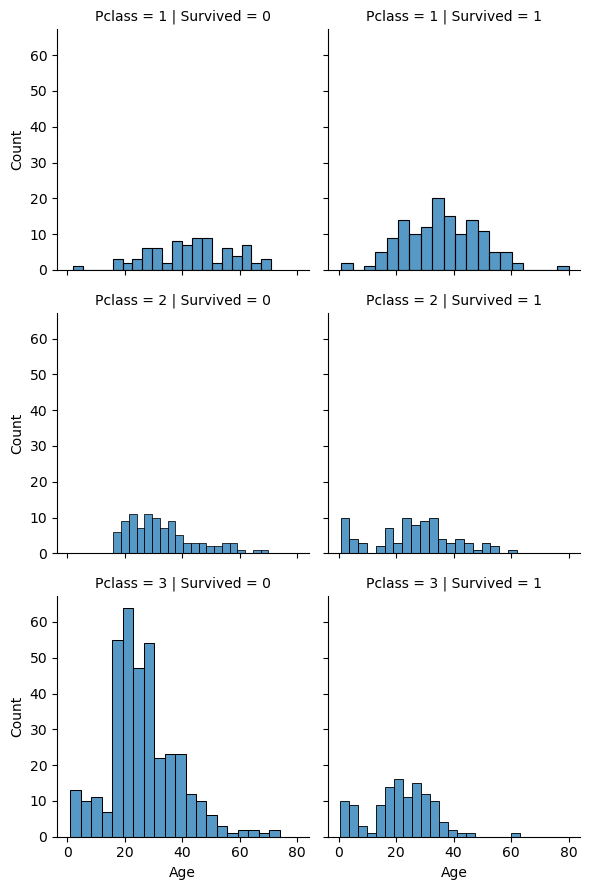

In [16]:
g = sns.FacetGrid(df, col='Survived', row='Pclass', height=3)
g.map(sns.histplot, 'Age', bins=20)

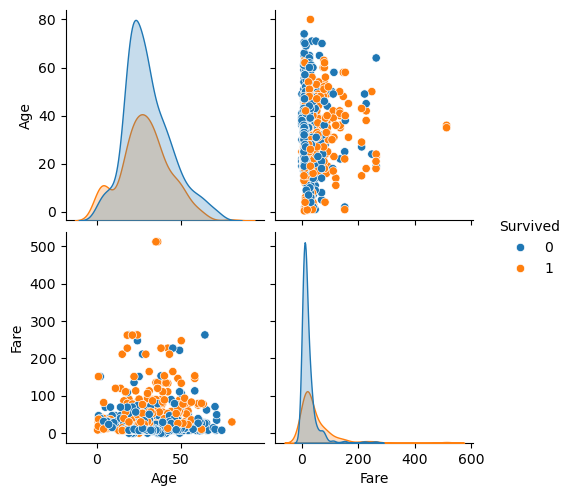

In [18]:
sns.pairplot(df[['Age', 'Fare', 'Survived']], hue='Survived')